In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
from google.colab import files
uploaded = files.upload()

Saving waste_generation_dataset.xlsx to waste_generation_dataset (1).xlsx


In [4]:
import pandas as pd

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

df.head()

,Population,Household_Size,Income_Level,Commercial_Activity,Collection_Frequency,Season,Past_Waste,Waste_Generated
0,4174,3,High,2,3,Summer,567,599
1,4507,4,Low,2,2,Monsoon,586,650
2,1860,5,High,2,6,Summer,328,372
3,2294,3,Medium,6,6,Monsoon,371,384
4,2130,6,Low,3,2,Winter,290,387


In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (120, 8)

Columns: Index(['Population', 'Household_Size', 'Income_Level', 'Commercial_Activity',
       'Collection_Frequency', 'Season', 'Past_Waste', 'Waste_Generated'],
      dtype='object')

Data Types:
 Population               int64
Household_Size           int64
Income_Level            object
Commercial_Activity      int64
Collection_Frequency     int64
Season                  object
Past_Waste               int64
Waste_Generated          int64
dtype: object

Missing Values:
 Population              0
Household_Size          0
Income_Level            0
Commercial_Activity     0
Collection_Frequency    0
Season                  0
Past_Waste              0
Waste_Generated         0
dtype: int64


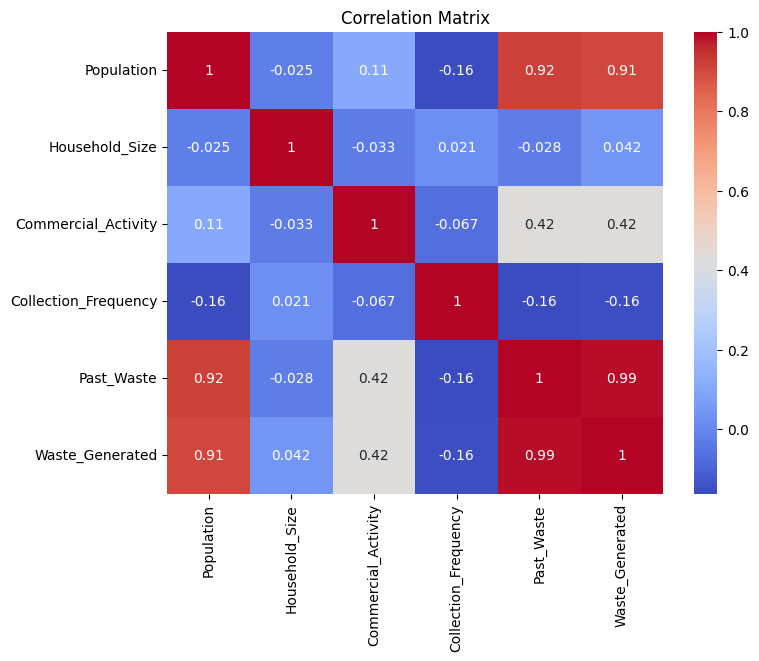

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

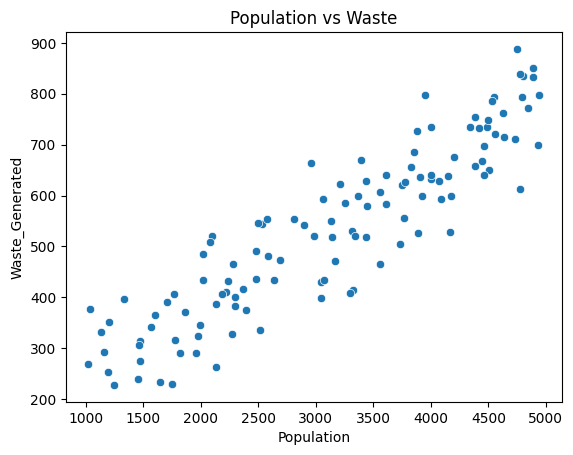

In [7]:
# Population vs Waste
sns.scatterplot(x="Population", y="Waste_Generated", data=df)
plt.title("Population vs Waste")
plt.show()

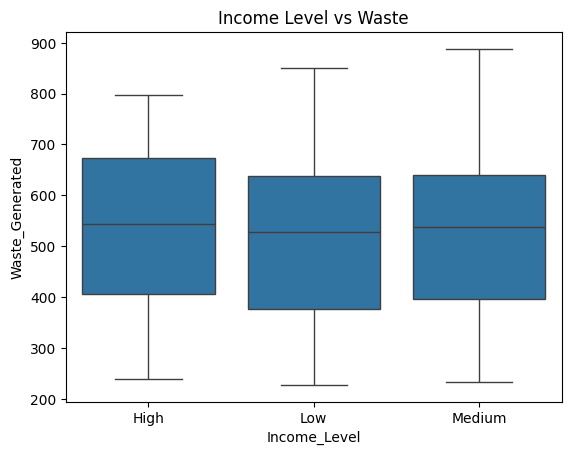

In [8]:
# Income Level vs Waste
sns.boxplot(x="Income_Level", y="Waste_Generated", data=df)
plt.title("Income Level vs Waste")
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

le_income = LabelEncoder()
le_season = LabelEncoder()

df['Income_Level'] = le_income.fit_transform(df['Income_Level'])
df['Season'] = le_season.fit_transform(df['Season'])

df.head()

,Population,Household_Size,Income_Level,Commercial_Activity,Collection_Frequency,Season,Past_Waste,Waste_Generated
0,4174,3,0,2,3,1,567,599
1,4507,4,1,2,2,0,586,650
2,1860,5,0,2,6,1,328,372
3,2294,3,2,6,6,0,371,384
4,2130,6,1,3,2,2,290,387


In [10]:
X = df.drop("Waste_Generated", axis=1)
y = df["Waste_Generated"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 29.036249999999995
RMSE: 34.17716397684278
R2 Score: 0.9589811154917377


In [14]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
6,Past_Waste,0.982535
0,Population,0.005807
2,Income_Level,0.003604
3,Commercial_Activity,0.002566
4,Collection_Frequency,0.002200
5,Season,0.001694
1,Household_Size,0.001594


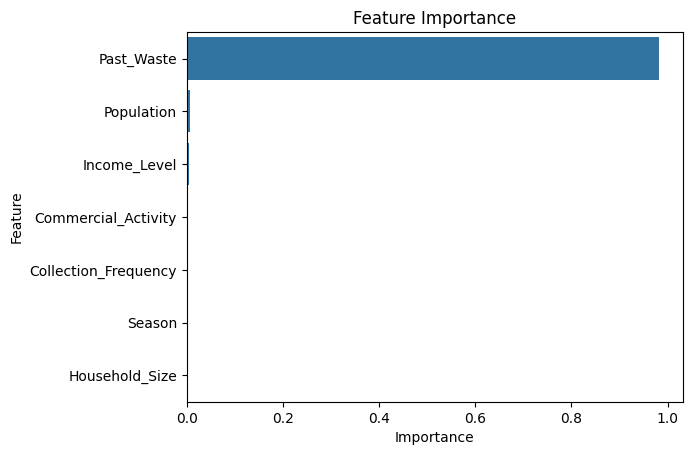

In [15]:
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

In [16]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(le_income, open("income_encoder.pkl", "wb"))
pickle.dump(le_season, open("season_encoder.pkl", "wb"))

In [17]:
files.download("model.pkl")
files.download("income_encoder.pkl")
files.download("season_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# LINEAR REGRESSION

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("🔹 Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

🔹 Linear Regression Results
MAE: 21.64802632188491
RMSE: 27.176032325757355
R2 Score: 0.9740651403289475


In [19]:
# DECISION TREE

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("\n🔹 Decision Tree Results")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))


🔹 Decision Tree Results
MAE: 36.34305555555556
RMSE: 45.42869387129518
R2 Score: 0.927527656922394


In [20]:
# GRADIENT BOOSTING

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Prediction
y_pred_gb = gb_model.predict(X_test)

# Evaluation
print("\n🔹 Gradient Boosting Results")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2 Score:", r2_score(y_test, y_pred_gb))


🔹 Gradient Boosting Results
MAE: 30.323480618722716
RMSE: 36.05885751754044
R2 Score: 0.9543400189903162


In [21]:
# MODEL COMPARISON

import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_gb)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.974065
1,Decision Tree,0.927528
2,Gradient Boosting,0.954340


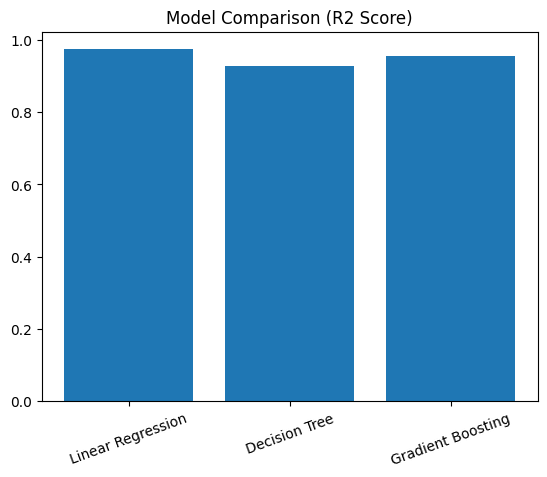

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=20)
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(name, y_test, y_pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    }

evaluation_results = []

evaluation_results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))
evaluation_results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
evaluation_results.append(evaluate_model("Random Forest", y_test, y_pred))
evaluation_results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))

eval_df = pd.DataFrame(evaluation_results)
eval_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,21.648026,738.536733,27.176032,0.974065
1,Decision Tree,36.343056,2063.766227,45.428694,0.927528
2,Random Forest,29.036250,1168.078537,34.177164,0.958981
3,Gradient Boosting,30.323481,1300.241205,36.058858,0.954340


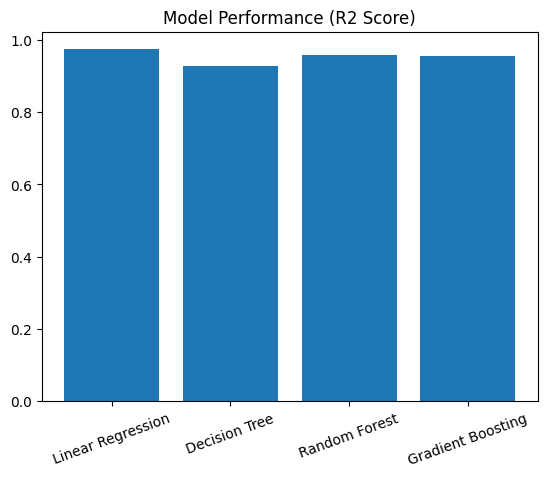

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(eval_df["Model"], eval_df["R2 Score"])
plt.title("Model Performance (R2 Score)")
plt.xticks(rotation=20)
plt.show()

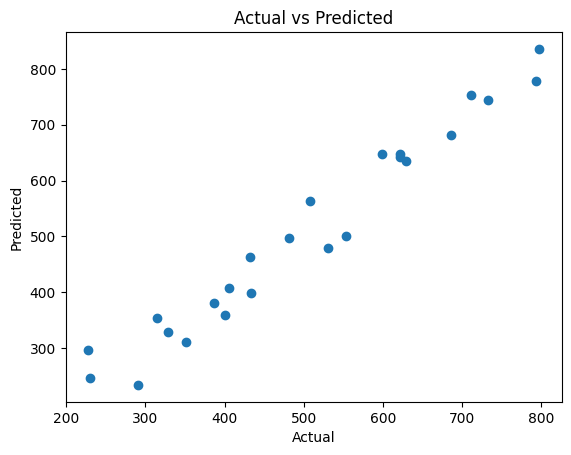

In [25]:
plt.scatter(y_test, y_pred_gb)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()